In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nias-ia/covid_19_clean_complete.csv
/kaggle/input/nias-ia/country_wise_latest.csv
/kaggle/input/nias-ia/day_wise.csv
/kaggle/input/nias-ia/exerciciopandas.py
/kaggle/input/nias-ia/usa_county_wise.csv
/kaggle/input/nias-ia/worldometer_data.csv
/kaggle/input/nias-ia/full_grouped.csv


# **5.1 line chart**

In [2]:
#importing libraries which will be useful to plot
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
print("setup complete")

setup complete


In [3]:
covid_filepath = '/kaggle/input/nias-ia/covid_19_clean_complete.csv'
covid_clean_complete = pd.read_csv(covid_filepath)
covid_clean = covid_clean_complete.rename(columns={
    "Province/State": "Province_State",
    "Country/Region": "Country_Region",
    "WHO Region": "WHO_Region"
})
covid_clean['Date'] = pd.to_datetime(covid_clean['Date'])
covid_data = covid_clean.drop(columns=['Lat','Long','Confirmed','Recovered','Active','Province_State','Country_Region']) #droping columns unused
covid_df = covid_data.groupby(['WHO_Region','Date']).sum()
covid_df

Deaths
WHO_Region      Date              
Africa          2020-01-22       0
                2020-01-23       0
                2020-01-24       0
                2020-01-25       0
                2020-01-26       0
...                            ...
Western Pacific 2020-07-23    8131
                2020-07-24    8148
                2020-07-25    8180
                2020-07-26    8225
                2020-07-27    8249

[1128 rows x 1 columns]

In [4]:
covid_plt = pd.pivot_table(covid_df,values = 'Deaths', index = 'Date',columns = ['WHO_Region'])#adjusting the data frame to plot the line graph
covid_plt

WHO_Region,Africa,Americas,Eastern Mediterranean,Europe,South-East Asia,Western Pacific
Date,,,,,,
2020-01-22,0,0,0,0,0,17
2020-01-23,0,0,0,0,0,18
2020-01-24,0,0,0,0,0,26
2020-01-25,0,0,0,0,0,42
2020-01-26,0,0,0,0,0,56
...,...,...,...,...,...,...
2020-07-23,10978,330007,36575,209704,38111,8131
2020-07-24,11315,333968,37033,210193,38993,8148
2020-07-25,11683,336817,37467,210587,39783,8180


Text(0, 0.5, 'deaths')

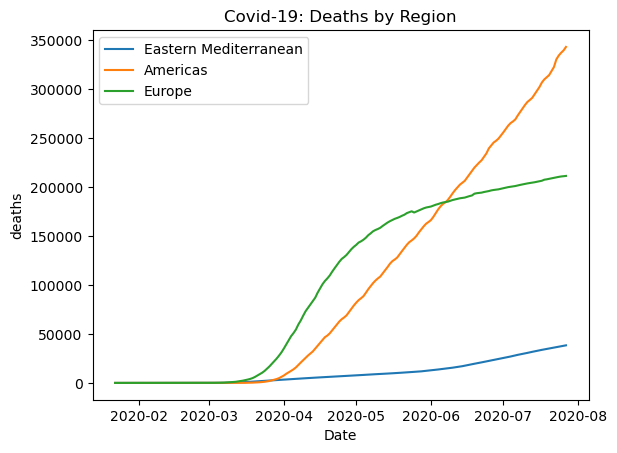

In [5]:
# Add title
plt.title("Covid-19: Deaths by Region")

# Line chart showing the Eastern Mediterranean Deaths by covid-19
sns.lineplot(data=covid_plt['Eastern Mediterranean'], label="Eastern Mediterranean")

# Line chart showing the Americas Deaths by covid-19
sns.lineplot(data=covid_plt['Americas'], label="Americas")

#Line chart showing the Europe Deaths by covid-19
sns.lineplot(data=covid_plt['Europe'], label="Europe")

# Add label for horizontal axis 
plt.xlabel("Date")

# Add label for vertical axis
plt.ylabel("deaths")

# **5.2 Bar Charts**

Agora deve-se produzir um gráfico bar chart, indicando o número de mortes em cada
continente (OBS: utilize o dataframe criado no exercício 4.1 - 4)
 1. Editar o tamanho do gráfico, como sugestão, coloque o tamanho (10,6
 2. Plotar gráfico bar chart das mortes nos continentes
 3. editar título e nome dos eixos
 4. Responder perguntas com base no gráfico

**copiei o codigo novamente, pois quando fui tentar importar o meu código apagou todo**

In [6]:
China = covid_clean.loc[covid_clean.Country_Region == 'China']#filtering only the china province
sum_province = China.groupby('Province_State').sum() #grouping the provinces 
china_covid_data = sum_province.drop(columns=['Lat','Long']) #droping columns unused
china_df = china_covid_data.drop_duplicates(subset=['Confirmed'])#droping duplicated rows
china_covid_maxcases = china_df.sort_values(by=['Confirmed'], ascending=False)#sorting the covid cases confirmed by biggers numbers
china_covid_maxcaschina_covid_data = sum_province.drop(columns=['Lat','Long']) #droping columns unusedes.head() #showing the data frame

In [7]:
world = pd.read_csv('/kaggle/input/nias-ia/worldometer_data.csv')
world_meter = world.rename(columns={
    "Serious,Critical": "Serious_Critical",
    "Country/Region": "Country_Region",
    "Tot Cases/1M pop": "Tot_Cases_1M_pop",
    "Deaths/1M pop": "Deaths_1M_pop",
    "Tests/1M pop":"Tests_1M_pop"
})

world_meter

,Country_Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,Serious_Critical,Tot_Cases_1M_pop,Deaths_1M_pop,TotalTests,Tests_1M_pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Montserrat,North America,4.992000e+03,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,2.624700e+04,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3.489000e+03,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,8.010000e+02,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe


In [8]:
covid_clean.groupby('Country_Region').sum()

,Lat,Long,Confirmed,Deaths,Recovered,Active
Country_Region,,,,,,
Afghanistan,6380.552680,12729.471164,1936390,49098,798240,1089052
Albania,7736.820400,3791.640400,196702,5708,118877,72117
Algeria,5270.373200,312.004800,1179755,77972,755897,345886
Andorra,7991.184400,286.098400,94404,5423,69074,19907
Angola,-2106.107600,3360.293200,22662,1078,6573,15011
...,...,...,...,...,...,...
West Bank and Gaza,6007.013600,6623.841600,233461,1370,61124,170967
Western Sahara,4552.514000,-2422.530400,901,63,648,190
Yemen,2923.912676,9121.080944,67180,17707,23779,25694


In [9]:
covid_merge  =  pd.merge(world_meter, covid_clean, on='Country_Region')
world_covid = covid_merge.loc[:, ['TotalDeaths', 'Continent','Population']]
covid_deaths_percent = world_covid.drop_duplicates(subset=['Population'])
covid_grouped = covid_deaths_percent.groupby('Continent').sum()
covid_grouped

,TotalDeaths,Population
Continent,,
Africa,21635.0,1.215738e+09
Asia,99816.0,3.020510e+09
Australia/Oceania,281.0,4.039107e+07
Europe,158748.0,6.794130e+08
North America,66986.0,2.568683e+08
South America,154838.0,4.308076e+08


In [10]:
droped_df = covid_grouped.drop(columns= 'Population') #droping columns unused

In [11]:
deaths_continent = pd.pivot_table(droped_df,values = 'TotalDeaths', columns = ['Continent'])#adjusting the data frame to plot the line graph
deaths_continent 

Continent,Africa,Asia,Australia/Oceania,Europe,North America,South America
TotalDeaths,21635.0,99816.0,281.0,158748.0,66986.0,154838.0


Text(0, 0.5, 'Deaths')

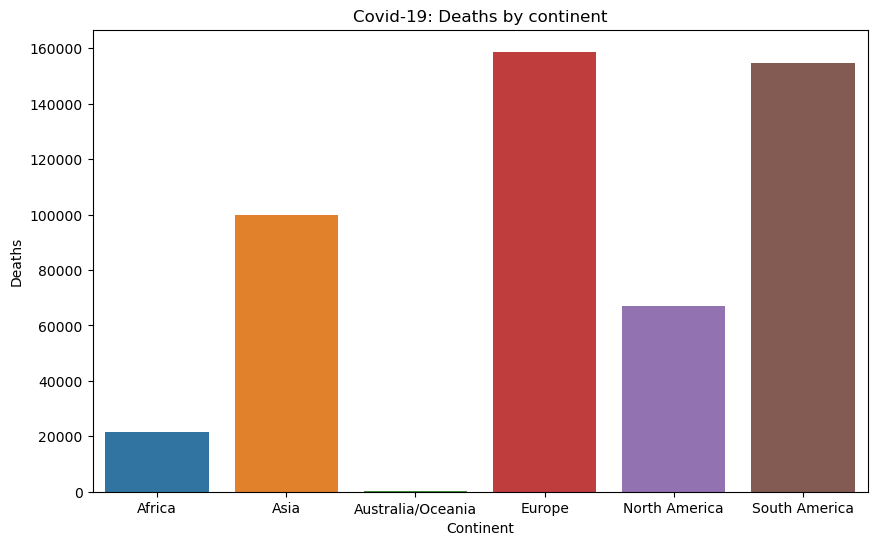

In [12]:
plt.figure(figsize=(10,6))

# Add title
plt.title("Covid-19: Deaths by continent")

# Bar chart showing average arrival delay for Spirit Airlines flights by month
sns.barplot(data = deaths_continent)

# Add label for vertical axis
plt.ylabel("Deaths")

# **5.3 - Scatter Plots**

1. Descobrir se há relação entre o número de mortes por milhão e a quantidade de
habitantes, nos 3 continentes com maior média de mortes por milhão de habitantes, por meio de scatter plot (OBS: Utilizar somente arquivo “worldometer_data.csv”) 
2. Agrupar o dataframe pela coluna “Continent”, retirar apenas os dados de "Deaths/1 M pop", utilizar “mean” como função de agregação e ordenar para descobrir os 3 continentes com maior valor 
3. Obter apenas os dados do dataframe, correspondentes a esses continentes 
4. Criar Scatterplot sendo o eixo x mostrando as mortes por milhão, o eixo y, a população total e representar os 3 continentes com cores diferentes 
5. Responder as perguntas com base no gráfico

In [13]:
#grouping the data frame by continent
#df_worldm_sum = world_meter.groupby('Continent').sum()
w_meter = world_meter.groupby(['Deaths_1M_pop','Continent']).mean()

# using drop for treat the data, filtering only necessaries columns
world_dataf = w_meter.drop(columns= ['TotalCases','NewCases','TotalDeaths','NewDeaths','TotalRecovered','NewRecovered','ActiveCases','Serious_Critical','Tot_Cases_1M_pop','TotalTests','Tests_1M_pop'])

#filtering only those tree continents with most biggest value of average deaths by milion
wm_df = world_dataf.sort_values(by='Deaths_1M_pop', ascending=False)
wm_df
#world_plotable = wm_df.loc[['Continent']] --FALTA FILTRAR OS CONTINENTES SE VIRA AI FILHONA
#world_plotable

Population
Deaths_1M_pop Continent                    
1238.00       Europe                33938.0
850.00        Europe             11594739.0
683.00        Europe             67922029.0
673.00        Europe                77278.0
619.00        South America      33016319.0
...                                     ...
0.30          Australia/Oceania   8963009.0
              Asia               23821199.0
0.10          Asia               75935929.5
              Africa             45867852.0
0.08          Africa             11922216.0

[149 rows x 1 columns]

<AxesSubplot:xlabel='Deaths_1M_pop', ylabel='Population'>

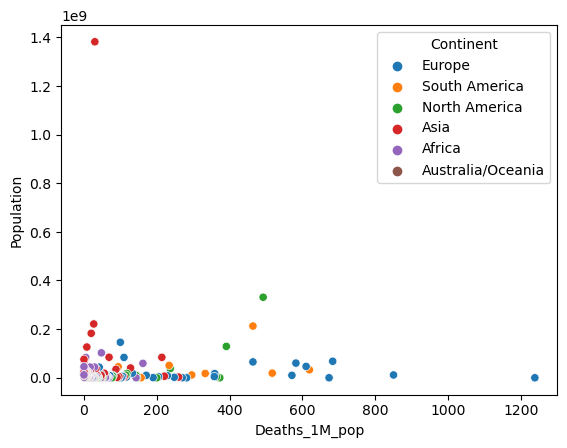

In [14]:
sns.scatterplot(x="Deaths_1M_pop",y="Population",hue="Continent",data=wm_df)

# **5.4 - Heatmap de Correlação**

1. Será utilizado o método DataFrame.corr() do pandas para gerar os valores de correlação, então o aluno deverá produzir um heatmap para a visualização dos valores gerados
2. Criar uma variável para armazenar os valores de correlação 
3. Criar um heatmap, com título, utilizando a variável criada no item anterior 
4. Escolher duas features para analisar seus valores de correlação (Sugestão: “Population”, “Teste/1M pop”)

In [15]:
#Generate values of correlation 
corr_df = world_meter.corr(method='pearson')
corr_df

,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,Serious_Critical,Tot_Cases_1M_pop,Deaths_1M_pop,TotalTests,Tests_1M_pop
Population,1.000000,0.546158,0.889610,0.431072,0.910836,0.590239,0.854194,0.459124,0.595379,-0.009337,0.025686,0.497937,-0.075129
TotalCases,0.546158,1.000000,0.999459,0.938622,0.998062,0.985764,0.998258,0.969423,0.967270,0.252627,0.280476,0.891001,0.029141
NewCases,0.889610,0.999459,1.000000,0.991894,0.995554,0.991416,0.999636,0.935500,0.985526,0.321203,0.842468,0.214572,-0.669339
TotalDeaths,0.431072,0.938622,0.991894,1.000000,0.999507,0.935410,0.988362,0.927625,0.906627,0.237206,0.425186,0.850304,0.053870
NewDeaths,0.910836,0.998062,0.995554,0.999507,1.000000,0.998935,0.992651,0.888717,0.997112,0.046499,0.751519,0.039460,-0.803470
TotalRecovered,0.590239,0.985764,0.991416,0.935410,0.998935,1.000000,0.986012,0.914566,0.949628,0.268483,0.296443,0.870113,0.022027
NewRecovered,0.854194,0.998258,0.999636,0.988362,0.992651,0.986012,1.000000,0.937663,0.980595,0.167036,0.825828,-0.081745,-0.869608
ActiveCases,0.459124,0.969423,0.935500,0.927625,0.888717,0.914566,0.937663,1.000000,0.945943,0.212899,0.255001,0.911488,0.028963
Serious_Critical,0.595379,0.967270,0.985526,0.906627,0.997112,0.949628,0.980595,0.945943,1.000000,0.209668,0.271842,0.859526,0.020649
Tot_Cases_1M_pop,-0.009337,0.252627,0.321203,0.237206,0.046499,0.268483,0.167036,0.212899,0.209668,1.000000,0.502134,0.194120,0.302728


<AxesSubplot:title={'center':'pearson correlation of the values of covid data base'}>

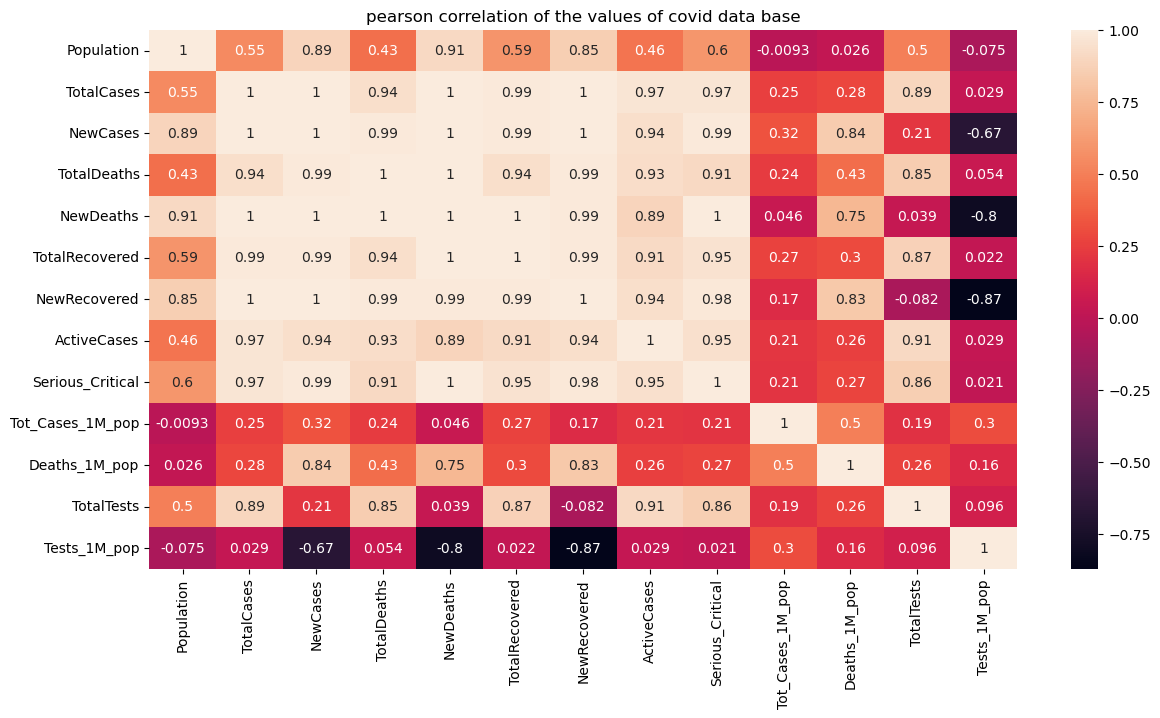

In [16]:
#ploting a heatmap with title using the variable created below 
plt.figure(figsize=(14,7))

# Add title
plt.title("pearson correlation of the values of covid data base")

# Heatmap showing average arrival delay for each airline by month
sns.heatmap(data=corr_df, annot=True)